In [1]:
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource

%matplotlib inline

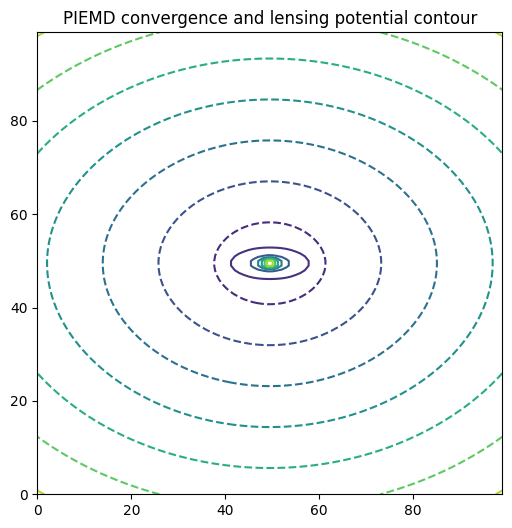

In [2]:
src = DiskSource(100, 10)
df = PIEMD(source=src, theta_E=1.0, q=0.4, s=0, phi=0)

kappa = df.get_convergence()
psi = df.get_potential()

plt.figure(figsize=(6,6))
plt.contour(kappa)
plt.contour(psi, linestyles="--")
plt.title("PIEMD convergence and lensing potential contour")
plt.show()

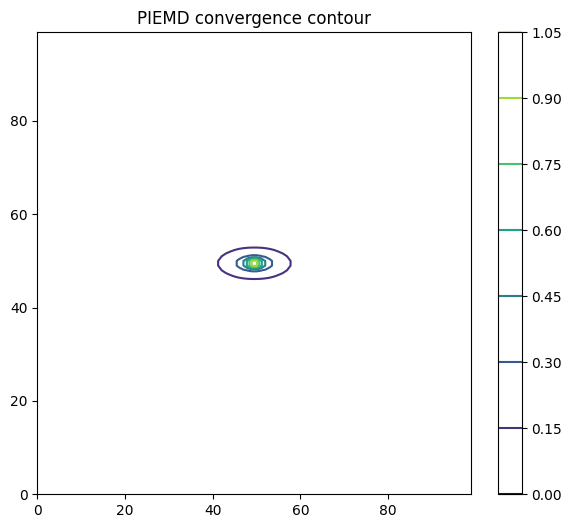

In [3]:
plt.figure(figsize=(7,6))
cbar = plt.contour(kappa)
plt.colorbar(cbar)
plt.title("PIEMD convergence contour")
plt.show()

In [4]:
src = DiskSource(50, 2)
# src.pad()
df = PIEMD(source=src, theta_E=10 ,q=1, s=0, phi=0)

img = df.get_image()

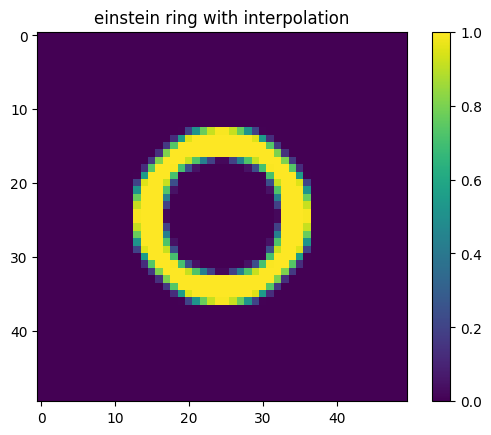

In [5]:
cbar = plt.imshow(img)
plt.colorbar(cbar)
plt.title("einstein ring with interpolation")
plt.savefig("figures_out/interpolate_example.png")
plt.show()

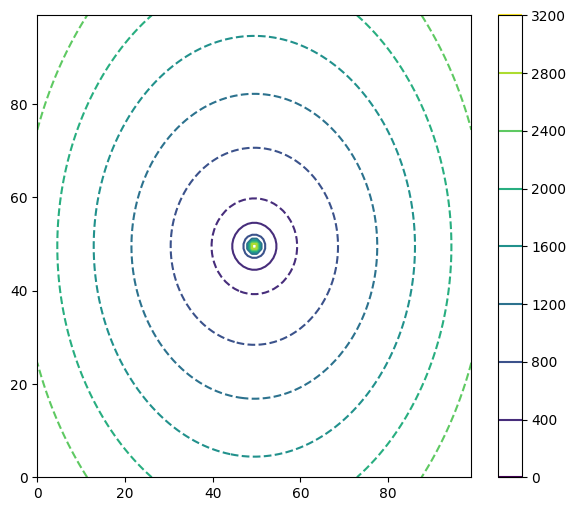

In [6]:
plt.figure(figsize=(7,6))
src = DiskSource(100, 10)
df = PIEMD(source=src, theta_E=40, gamma_1=0.1, gamma_2=0)
kappa = df.get_convergence()
phi = df.get_potential()

plt.contour(kappa)
cbar = plt.contour(phi, linestyles="--")
plt.colorbar(cbar)
plt.show()

In [7]:
src = DiskSource(1001, 300)
src.pad(1000)
df = PIEMD(source=src, theta_E=400, gamma_1=-0.2, gamma_2=0.1)

img = df.get_image()

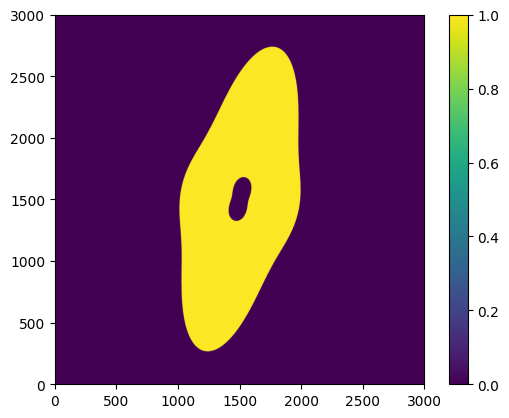

In [8]:
cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)
plt.show()

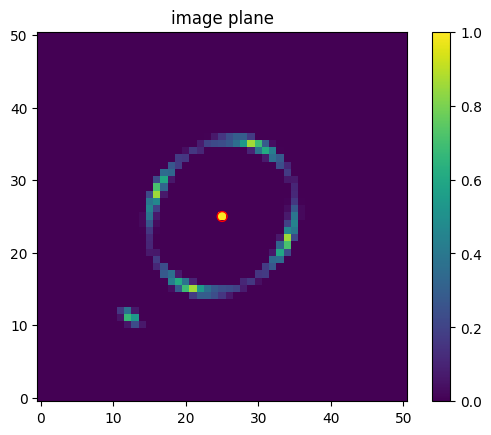

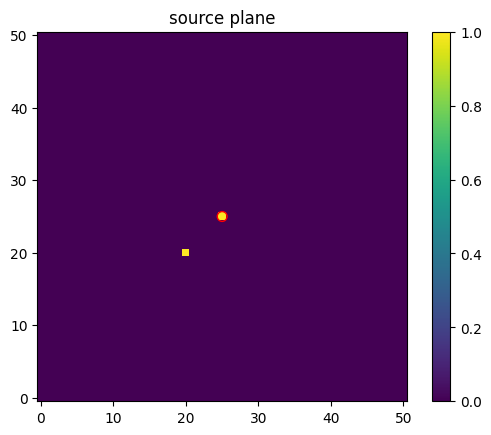

In [9]:
arr = np.zeros((51,51))
arr[25,25] = 1
arr[20,20] = 1
src = Source(arr)
df = PIEMD(src, 10, q=0.8, s=1, gamma_1=0.01, gamma_2=0.03)

img = df.get_image()

cbar = plt.imshow(img, origin="lower")
plt.colorbar(cbar)

y_vec, x_vec = np.where(img > 0.5)
i = np.random.randint(x_vec.shape)
x, y = x_vec[i], y_vec[i]

r = [x,y]
beta_x, beta_y = df.map(r)
plt.scatter(x=x, y=y, facecolors='none', edgecolors='red', s=50)  # s controls size
plt.title("image plane")
plt.savefig("figures_out/ray_tracing_image.png")
plt.show()

cbar = plt.imshow(arr, origin="lower")
plt.colorbar(cbar)
plt.scatter(x=beta_x, y=beta_y, facecolors="none", edgecolors="red", s=50)
plt.title("source plane")
plt.savefig("figures_out/ray_tracing_source.png")
plt.show()

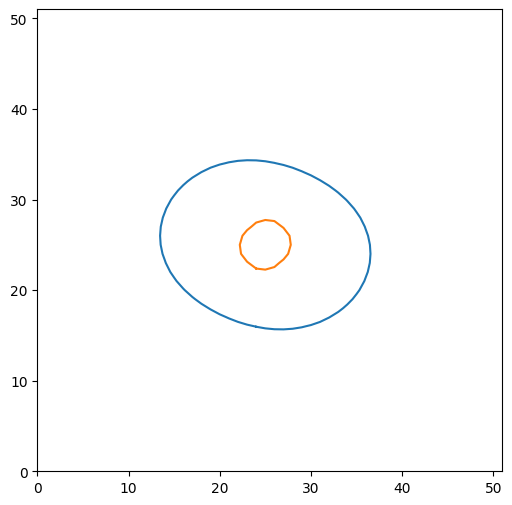

In [10]:
plt.figure(figsize=(6,6))
critical_curves = df.get_critical_curves()
for polygon in critical_curves:
    plt.plot(polygon[:, 0], polygon[:,1], '-')

plt.xlim(0, 51)
plt.ylim(0, 51)
plt.show()

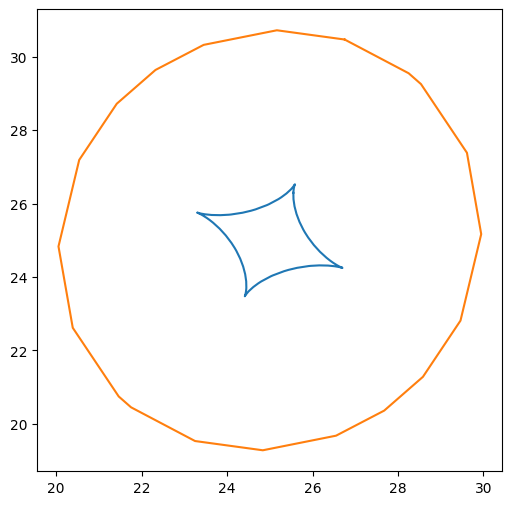

In [11]:
plt.figure(figsize=(6,6))
caustics = df.get_caustics()

for polygon in caustics:
    plt.plot(polygon[:, 0], polygon[:, 1])
plt.show()

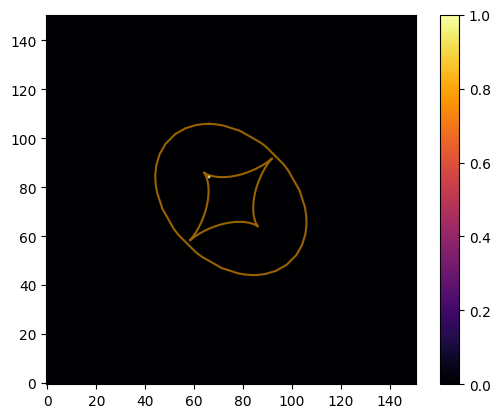

In [23]:
# %matplotlib qt
arr = np.zeros((151,151))
arr[84,66]=1

src = Source(arr)
df = PIEMD(src, 30, q=0.5, s=1, phi=np.pi/4)

caustics = df.get_caustics()

cbar = plt.imshow(df.source.array, cmap='inferno', origin='lower')
plt.colorbar(cbar)

for curve in caustics:
    plt.plot(curve[:,0], curve[:,1], c='orange', alpha=0.6)

plt.show()

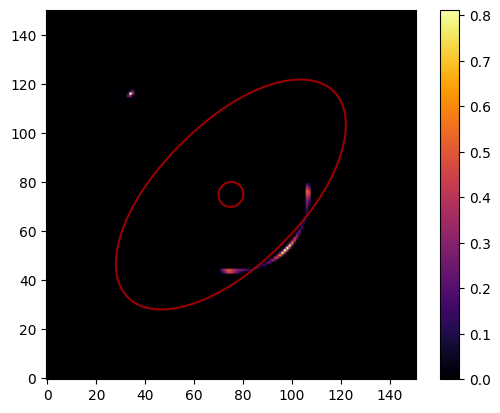

In [24]:
cbar = plt.imshow(df.get_image(), cmap='inferno', origin='lower')
plt.colorbar(cbar)

for curve in df.get_critical_curves():
    plt.plot(curve[:,0], curve[:,1], c='red', alpha=0.6)

plt.show()